# Modeling Dataset Exploratory Analysis

This notebook inspects the combined modeling dataset created after price-cache download, event-date alignment, leakage-safe feature engineering, and abnormal-move label construction.

- Analyze generated `data/processed/modeling_dataset.csv`.
- Review row retention and dropped-row reasons.
- Check target distributions by split, ticker, and volatility regime.
- Inspect feature missingness and distributions.
- Document leakage checks: features use information through `t-1`; targets use `close(t)` to `close(t+1)`.

In [1]:
from pathlib import Path
import os

os.environ.setdefault("MPLCONFIGDIR", "/tmp/marketmood-matplotlib")
Path(os.environ["MPLCONFIGDIR"]).mkdir(parents=True, exist_ok=True)

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

pd.set_option("display.max_columns", 120)
pd.set_option("display.max_colwidth", 160)
pd.set_option("display.max_rows", 100)

PROJECT_ROOT = Path.cwd().resolve().parent if Path.cwd().name == "notebooks" else Path.cwd().resolve()
STOCKEMO_DIR = PROJECT_ROOT / "data" / "stockemo"
PROCESSED_DIR = PROJECT_ROOT / "data" / "processed"
MODELING_PATH = PROCESSED_DIR / "modeling_dataset.csv"
DROPPED_PATH = PROCESSED_DIR / "modeling_dataset_dropped_rows.csv"
CLASS_DISTRIBUTION_PATH = PROCESSED_DIR / "modeling_dataset_class_distribution.csv"

MODELING_PATH

PosixPath('/Users/hanwang/projects/aipi540-marketmood/data/processed/modeling_dataset.csv')

## Load Modeling Outputs

In [2]:
date_columns = ["date", "post_date", "event_date", "feature_cutoff_date", "target_end_date"]
modeling = pd.read_csv(MODELING_PATH, parse_dates=date_columns)
dropped = pd.read_csv(DROPPED_PATH) if DROPPED_PATH.exists() else pd.DataFrame()
saved_class_distribution = pd.read_csv(CLASS_DISTRIBUTION_PATH) if CLASS_DISTRIBUTION_PATH.exists() else pd.DataFrame()

stockemo_split_map = []
for split, filename in {
    "train": "train_stockemo.csv",
    "validation": "val_stockemo.csv",
    "test": "test_stockemo.csv",
}.items():
    split_ids = pd.read_csv(STOCKEMO_DIR / filename, usecols=["id"])
    split_ids["split"] = split
    stockemo_split_map.append(split_ids)
stockemo_split_map = pd.concat(stockemo_split_map, ignore_index=True)

if not dropped.empty and "split" not in dropped.columns:
    dropped = dropped.merge(stockemo_split_map, on="id", how="left")

modeling.shape, dropped.shape

((9940, 36), (60, 6))

In [3]:
modeling.head()

,id,date,ticker,emo_label,senti_label,original,processed,split,post_date,event_date,feature_cutoff_date,target_end_date,text_raw,text_ticker_aware,text_ticker_masked,text_input,ret_1d,ret_3d,ret_5d,ret_10d,ret_20d,vol_5d,vol_10d,vol_20d,volume_z_20d,sma_5,sma_20,close_to_sma20,high_low_range,gap_return,close_t,close_t_plus_1,future_return_1d,rolling_vol_20d,abnormal_score,target
0,109001,2020-01-02,DIS,optimism,bullish,$DIS when is the shorts squeeze is what I wanna know 🚂🚂🚂🚂🚂 💰,Disney when is the shorts squeeze is what I wanna know [locomotive] [money bag],test,2020-01-02,2020-01-02,2019-12-31,2020-01-03,$DIS when is the shorts squeeze is what I wanna know 🚂🚂🚂🚂🚂 💰,Target ticker: DIS. Post: $DIS when is the shorts squeeze is what I wanna know 🚂🚂🚂🚂🚂 💰,Target ticker: $TICKER. Post: $TICKER when is the shorts squeeze is what I wanna know 🚂🚂🚂🚂🚂 💰,$DIS when is the shorts squeeze is what I wanna know 🚂🚂🚂🚂🚂 💰,0.005982,-0.007344,-0.000346,-0.025798,-0.034016,0.007845,0.007835,0.007944,-1.048001,140.613812,141.763457,-0.010832,0.010768,0.030675,143.689270,142.041000,-0.011471,0.007944,-1.443908,negative
1,109002,2020-01-03,AAPL,excitement,bullish,"$AAPL I’m out for now!! I don’t think it’ll dip big, but if it does it’ll be nice🍎💰✨","Apple I’m out for now!! I don’t think it’ll dip big, but if it does it’ll be nice [red apple] [money bag] [sparkles]",test,2020-01-03,2020-01-03,2020-01-02,2020-01-06,"$AAPL I’m out for now!! I don’t think it’ll dip big, but if it does it’ll be nice🍎💰✨","Target ticker: AAPL. Post: $AAPL I’m out for now!! I don’t think it’ll dip big, but if it does it’ll be nice🍎💰✨","Target ticker: $TICKER. Post: $TICKER I’m out for now!! I don’t think it’ll dip big, but if it does it’ll be nice🍎💰✨","$AAPL I’m out for now!! I don’t think it’ll dip big, but if it does it’ll be nice🍎💰✨",0.022816,0.036404,0.056566,0.071110,0.157641,0.009830,0.009431,0.009311,0.424779,70.574838,67.237629,0.075794,0.018698,0.047224,71.630623,72.201401,0.007968,0.009311,0.855823,positive
2,109003,2020-01-07,PYPL,optimism,bullish,$PYPL Back Over $120+ where this belongs 💰,PayPal Back Over $120+ where this belongs [money bag],test,2020-01-07,2020-01-07,2020-01-06,2020-01-08,$PYPL Back Over $120+ where this belongs 💰,Target ticker: PYPL. Post: $PYPL Back Over $120+ where this belongs 💰,Target ticker: $TICKER. Post: $TICKER Back Over $120+ where this belongs 💰,$PYPL Back Over $120+ where this belongs 💰,0.012964,0.018489,0.007038,0.011848,0.053351,0.017482,0.012145,0.011410,0.403095,108.226704,106.890775,0.021829,0.025452,-0.002376,108.728355,110.859901,0.019604,0.011410,1.718237,positive
3,100067,2020-01-08,AAPL,confusion,bearish,$AAPL with all time highs again the market seems to enjoy war very much🤔,Apple with all time highs again the market seems to enjoy war very much [thinking face],test,2020-01-08,2020-01-08,2020-01-07,2020-01-09,$AAPL with all time highs again the market seems to enjoy war very much🤔,Target ticker: AAPL. Post: $AAPL with all time highs again the market seems to enjoy war very much🤔,Target ticker: $TICKER. Post: $TICKER with all time highs again the market seems to enjoy war very much🤔,$AAPL with all time highs again the market seems to enjoy war very much🤔,-0.004703,-0.006526,0.023566,0.067814,0.102250,0.012670,0.010595,0.009645,-0.299121,71.749608,68.412766,0.050416,0.011898,0.038207,73.017830,74.568787,0.021241,0.009645,2.202238,positive
4,109005,2020-01-08,BA,anger,bearish,"$BA Of course there were technical problems behind this crash, just like the other two! How many more planes have to crash before this company gets banned f...","Boeing Of course there were technical problems behind this crash, just like the other two! How many more planes have to crash before this company gets banne...",test,2020-01-08,2020-01-08,2020-01-07,2020-01-09,"$BA Of course there were technical problems behind this crash, just like the other two! How many more planes have to crash before this company gets banned f...","Target ticker: BA. Post: $

## Row Retention And Drop Analysis

In [4]:
retention_by_split = modeling.groupby("split").size().rename("kept_rows").to_frame()

if not dropped.empty and "split" in dropped.columns:
    dropped_by_split = dropped.groupby("split", dropna=False).size().rename("dropped_rows")
    retention_by_split = retention_by_split.join(dropped_by_split, how="outer")
else:
    retention_by_split["dropped_rows"] = 0

retention_by_split["dropped_rows"] = retention_by_split["dropped_rows"].fillna(0).astype(int)
retention_by_split["total_rows"] = retention_by_split["kept_rows"] + retention_by_split["dropped_rows"]
retention_by_split["kept_rate"] = (retention_by_split["kept_rows"] / retention_by_split["total_rows"]).round(4)

retention_by_split

,kept_rows,dropped_rows,total_rows,kept_rate
split,,,,
test,994,6,1000,0.9940
train,7947,53,8000,0.9934
validation,999,1,1000,0.9990


In [5]:
if dropped.empty:
    print("No dropped rows were logged.")
else:
    display(dropped["drop_reason"].value_counts().to_frame("rows"))
    display(pd.crosstab(dropped["ticker"], dropped["drop_reason"], margins=True).sort_values("All", ascending=False).head(15))
    display(dropped.head(15))

,rows
drop_reason,
incomplete_features_or_target,60


drop_reason,incomplete_features_or_target,All
ticker,,
ABNB,60,60
All,60,60


,id,ticker,date,event_date,drop_reason,split
0,107418,ABNB,2020-12-08,2020-12-10,incomplete_features_or_target,train
1,107442,ABNB,2020-12-08,2020-12-10,incomplete_features_or_target,train
2,107506,ABNB,2020-12-09,2020-12-10,incomplete_features_or_target,train
3,107517,ABNB,2020-12-10,2020-12-10,incomplete_features_or_target,train
4,107530,ABNB,2020-12-10,2020-12-10,incomplete_features_or_target,train
5,107540,ABNB,2020-12-10,2020-12-10,incomplete_features_or_target,train
6,107541,ABNB,2020-12-10,2020-12-10,incomplete_features_or_target,train
7,107546,ABNB,2020-12-10,2020-12-10,incomplete_features_or_target,train
8,107548,ABNB,2020-12-10,2020-12-10,incomplete_features_or_target,train
9,107549,ABNB,2020-12-10,2020-12-10,incomplete_features_or_target,train


## Leakage And Date-Window Checks

The intended convention is conservative: price features use data available through `feature_cutoff_date = t-1`; the target uses future return from `close(t)` to `close(t+1)`.

In [6]:
leakage_checks = pd.Series(
    {
        "feature_cutoff_before_event": bool((modeling["feature_cutoff_date"] < modeling["event_date"]).all()),
        "target_end_after_event": bool((modeling["target_end_date"] > modeling["event_date"]).all()),
        "post_date_on_or_before_event": bool((modeling["post_date"] <= modeling["event_date"]).all()),
        "event_date_missing": int(modeling["event_date"].isna().sum()),
        "feature_cutoff_missing": int(modeling["feature_cutoff_date"].isna().sum()),
        "target_end_missing": int(modeling["target_end_date"].isna().sum()),
    }
)

leakage_checks.to_frame("value")

,value
feature_cutoff_before_event,True
target_end_after_event,True
post_date_on_or_before_event,True
event_date_missing,0
feature_cutoff_missing,0
target_end_missing,0


In [7]:
window_examples = modeling[
    [
        "split",
        "ticker",
        "post_date",
        "event_date",
        "feature_cutoff_date",
        "target_end_date",
        "close_t",
        "close_t_plus_1",
        "future_return_1d",
        "target",
    ]
].head(12)

window_examples

,split,ticker,post_date,event_date,feature_cutoff_date,target_end_date,close_t,close_t_plus_1,future_return_1d,target
0,test,DIS,2020-01-02,2020-01-02,2019-12-31,2020-01-03,143.689270,142.041000,-0.011471,negative
1,test,AAPL,2020-01-03,2020-01-03,2020-01-02,2020-01-06,71.630623,72.201401,0.007968,positive
2,test,PYPL,2020-01-07,2020-01-07,2020-01-06,2020-01-08,108.728355,110.859901,0.019604,positive
3,test,AAPL,2020-01-08,2020-01-08,2020-01-07,2020-01-09,73.017830,74.568787,0.021241,positive
4,test,BA,2020-01-08,2020-01-08,2020-01-07,2020-01-09,329.410095,334.350708,0.014998,positive
5,test,TSLA,2020-01-08,2020-01-08,2020-01-07,2020-01-09,32.809334,32.089333,-0.021945,negative
6,test,DIS,2020-01-09,2020-01-09,2020-01-08,2020-01-10,140.421814,140.218201,-0.001450,neutral
7,test,TSLA,2020-01-09,2020-01-09,2020-01-08,2020-01-10,32.089333,31.876667,-0.006627,neutral
8,test,AAPL,2020-01-10,2020-01-10,2020-01-09,2020-01-13,74.737373,76.334076,0.021364,positive
9,test,AMZN,2020-01-10,2020-01-10,2020-01-09,2020-01-13,94.157997,94.565002,0.004323,neutral


## Target Distribution

In [8]:
target_counts = pd.crosstab(modeling["split"], modeling["target"], margins=True)
target_rates = pd.crosstab(modeling["split"], modeling["target"], normalize="index").round(3)

display(target_counts)
display(target_rates)
display(saved_class_distribution)

target,negative,neutral,positive,All
split,,,,
test,198,539,257,994
train,1721,4226,2000,7947
validation,230,515,254,999
All,2149,5280,2511,9940


target,negative,neutral,positive
split,,,
test,0.199,0.542,0.259
train,0.217,0.532,0.252
validation,0.230,0.516,0.254


,split,negative,neutral,positive,All
0,test,198,539,257,994
1,train,1721,4226,2000,7947
2,validation,230,515,254,999
3,All,2149,5280,2511,9940


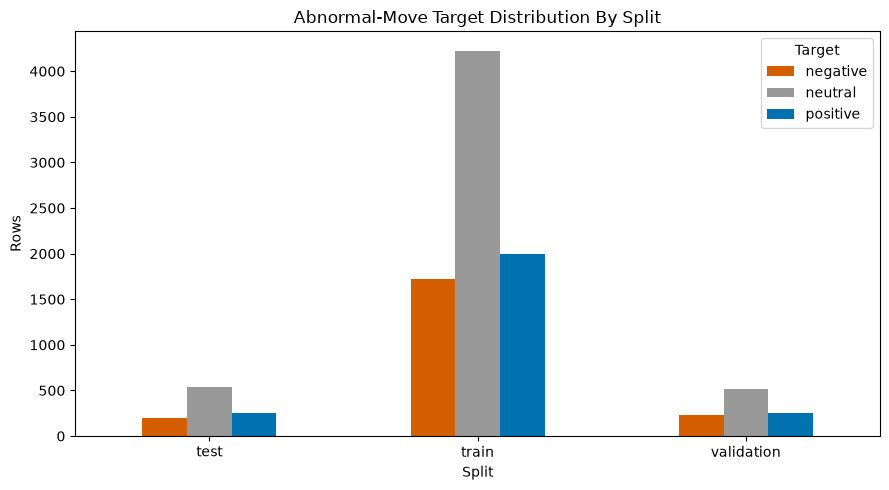

In [9]:
label_order = ["negative", "neutral", "positive"]
plot_counts = target_counts.drop(index="All", errors="ignore").reindex(columns=label_order)

fig, ax = plt.subplots(figsize=(9, 5))
plot_counts.plot(kind="bar", stacked=False, ax=ax, color=["#D55E00", "#999999", "#0072B2"])
ax.set_title("Abnormal-Move Target Distribution By Split")
ax.set_xlabel("Split")
ax.set_ylabel("Rows")
ax.legend(title="Target")
plt.xticks(rotation=0)
plt.tight_layout()

## Sentiment And Emotion Versus Abnormal-Move Target

StockEmotions provides `senti_label` and `emo_label` annotations for each post. The target in this project is different: it is based on the ticker's next trading-day abnormal return after the post. These views check whether the existing text annotations line up with the constructed market-move target or capture a different dimension.

In [10]:
sentiment_target_counts = pd.crosstab(modeling["senti_label"], modeling["target"])[label_order]
sentiment_target_rates = pd.crosstab(
    modeling["senti_label"],
    modeling["target"],
    normalize="index",
)[label_order].round(3)

display(sentiment_target_counts)
display(sentiment_target_rates)

target,negative,neutral,positive
senti_label,,,
bearish,953,2329,1213
bullish,1196,2951,1298


target,negative,neutral,positive
senti_label,,,
bearish,0.212,0.518,0.270
bullish,0.220,0.542,0.238


In [11]:
emotion_target_counts = pd.crosstab(modeling["emo_label"], modeling["target"])[label_order]
emotion_target_rates = pd.crosstab(
    modeling["emo_label"],
    modeling["target"],
    normalize="index",
)[label_order].round(3)

display(emotion_target_counts.sort_index())
display(emotion_target_rates.sort_index())

target,negative,neutral,positive
emo_label,,,
ambiguous,225,430,213
amusement,178,426,212
anger,87,192,105
anxiety,263,742,351
belief,189,494,220
confusion,129,325,150
depression,49,106,50
disgust,256,697,317
excitement,306,736,336


target,negative,neutral,positive
emo_label,,,
ambiguous,0.259,0.495,0.245
amusement,0.218,0.522,0.260
anger,0.227,0.500,0.273
anxiety,0.194,0.547,0.259
belief,0.209,0.547,0.244
confusion,0.214,0.538,0.248
depression,0.239,0.517,0.244
disgust,0.202,0.549,0.250
excitement,0.222,0.534,0.244


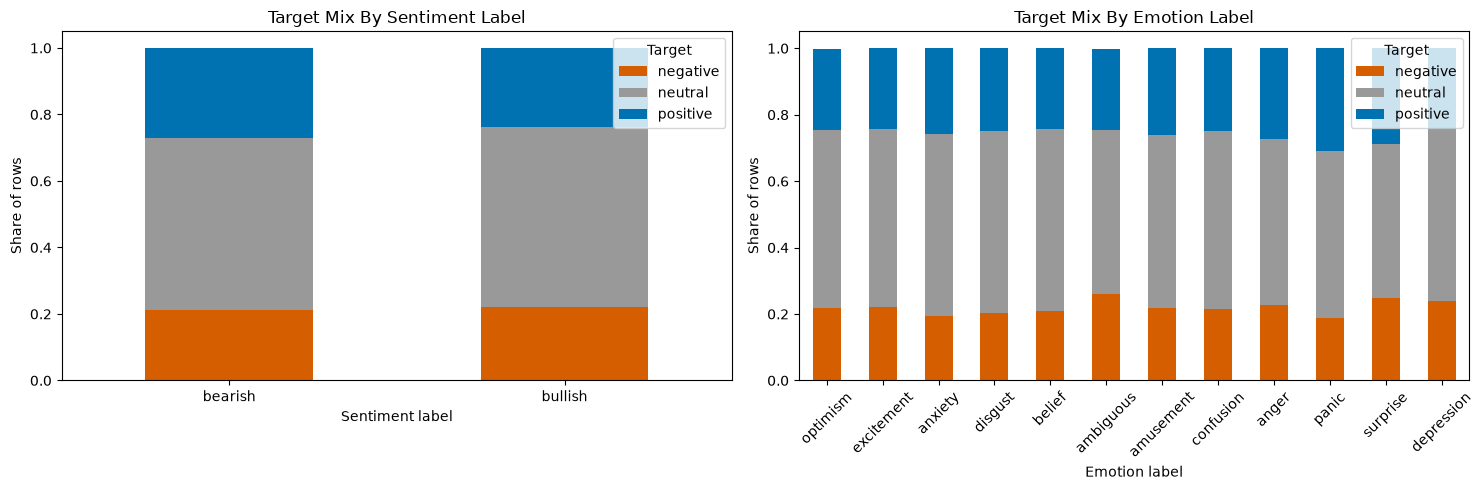

In [12]:
fig, axes = plt.subplots(1, 2, figsize=(15, 5))

sentiment_target_rates.plot(
    kind="bar",
    stacked=True,
    ax=axes[0],
    color=["#D55E00", "#999999", "#0072B2"],
)
axes[0].set_title("Target Mix By Sentiment Label")
axes[0].set_xlabel("Sentiment label")
axes[0].set_ylabel("Share of rows")
axes[0].legend(title="Target", loc="upper right")
axes[0].tick_params(axis="x", rotation=0)

emotion_target_rates.reindex(emotion_target_counts.sum(axis=1).sort_values(ascending=False).index).plot(
    kind="bar",
    stacked=True,
    ax=axes[1],
    color=["#D55E00", "#999999", "#0072B2"],
)
axes[1].set_title("Target Mix By Emotion Label")
axes[1].set_xlabel("Emotion label")
axes[1].set_ylabel("Share of rows")
axes[1].legend(title="Target", loc="upper right")
axes[1].tick_params(axis="x", rotation=45)

plt.tight_layout()

This chart shows that the new targets are independent of bearish/bullish and emotions.

In [13]:
overall_target_rate = modeling["target"].value_counts(normalize=True).reindex(label_order)

sentiment_lift = sentiment_target_rates.subtract(overall_target_rate, axis="columns").round(3)
emotion_lift = emotion_target_rates.subtract(overall_target_rate, axis="columns").round(3)

difference_summary = pd.Series(
    {
        "overall_negative_rate": overall_target_rate["negative"],
        "overall_neutral_rate": overall_target_rate["neutral"],
        "overall_positive_rate": overall_target_rate["positive"],
        "max_sentiment_positive_rate_gap": sentiment_target_rates["positive"].max() - sentiment_target_rates["positive"].min(),
        "max_emotion_positive_rate_gap": emotion_target_rates["positive"].max() - emotion_target_rates["positive"].min(),
        "max_sentiment_negative_rate_gap": sentiment_target_rates["negative"].max() - sentiment_target_rates["negative"].min(),
        "max_emotion_negative_rate_gap": emotion_target_rates["negative"].max() - emotion_target_rates["negative"].min(),
    }
).round(3)

display(difference_summary.to_frame("value"))
display(sentiment_lift)
display(emotion_lift.sort_index())

,value
overall_negative_rate,0.216
overall_neutral_rate,0.531
overall_positive_rate,0.253
max_sentiment_positive_rate_gap,0.032
max_emotion_positive_rate_gap,0.064
max_sentiment_negative_rate_gap,0.008
max_emotion_negative_rate_gap,0.070


target,negative,neutral,positive
senti_label,,,
bearish,-0.004,-0.013,0.017
bullish,0.004,0.011,-0.015


target,negative,neutral,positive
emo_label,,,
ambiguous,0.043,-0.036,-0.008
amusement,0.002,-0.009,0.007
anger,0.011,-0.031,0.020
anxiety,-0.022,0.016,0.006
belief,-0.007,0.016,-0.009
confusion,-0.002,0.007,-0.005
depression,0.023,-0.014,-0.009
disgust,-0.014,0.018,-0.003
excitement,0.006,0.003,-0.009


## Ticker-Level Coverage

In [14]:
ticker_coverage = (
    modeling.groupby("ticker")
    .agg(
        rows=("id", "size"),
        train_rows=("split", lambda values: int((values == "train").sum())),
        validation_rows=("split", lambda values: int((values == "validation").sum())),
        test_rows=("split", lambda values: int((values == "test").sum())),
        min_event_date=("event_date", "min"),
        max_event_date=("event_date", "max"),
        positive_rate=("target", lambda values: (values == "positive").mean()),
        neutral_rate=("target", lambda values: (values == "neutral").mean()),
        negative_rate=("target", lambda values: (values == "negative").mean()),
    )
    .sort_values("rows", ascending=False)
)

ticker_coverage.head(20)

,rows,train_rows,validation_rows,test_rows,min_event_date,max_event_date,positive_rate,neutral_rate,negative_rate
ticker,,,,,,,,,
TSLA,4341,3463,452,426,2020-01-02,2020-12-31,0.252246,0.550104,0.197650
AAPL,1721,1395,159,167,2020-01-02,2020-12-31,0.257990,0.505520,0.236490
BA,919,730,101,88,2020-01-07,2020-12-31,0.313384,0.511425,0.175190
DIS,432,355,36,41,2020-01-02,2020-12-30,0.250000,0.430556,0.319444
AMZN,407,319,49,39,2020-01-02,2020-12-31,0.257985,0.523342,0.218673
MSFT,271,208,28,35,2020-01-16,2020-12-31,0.254613,0.420664,0.324723
CCL,264,211,20,33,2020-02-07,2020-12-31,0.208333,0.518939,0.272727
BABA,239,192,19,28,2020-01-08,2020-12-31,0.209205,0.606695,0.184100
FB,204,158,24,22,2020-01-07,2020-12-31,0.279412,0.509804,0.210784


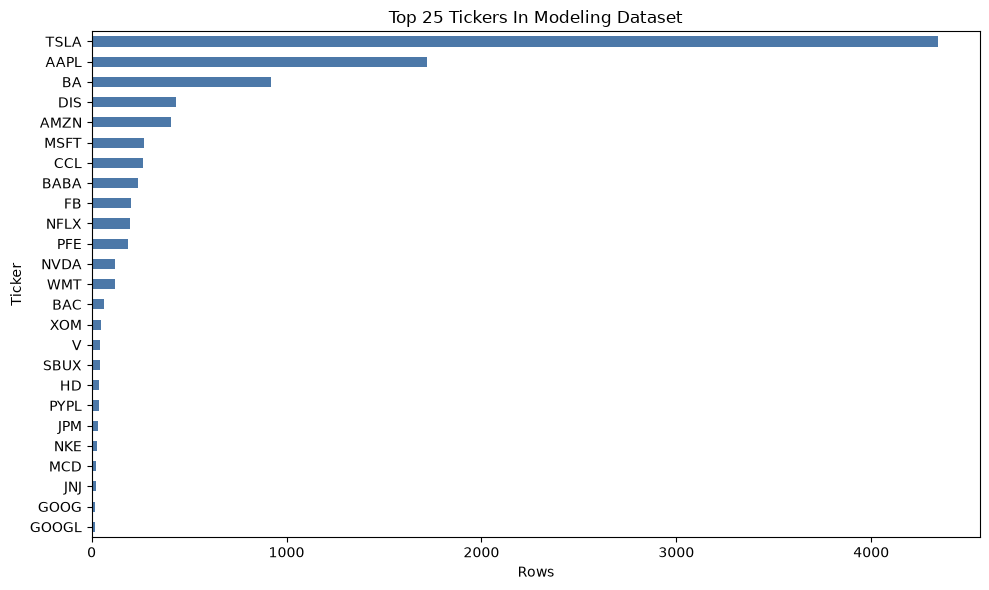

In [15]:
fig, ax = plt.subplots(figsize=(10, 6))
ticker_coverage["rows"].head(25).sort_values().plot(kind="barh", ax=ax, color="#4C78A8")
ax.set_title("Top 25 Tickers In Modeling Dataset")
ax.set_xlabel("Rows")
ax.set_ylabel("Ticker")
plt.tight_layout()

## Feature Missingness And Basic Summaries

In [16]:
price_features = [
    "ret_1d",
    "ret_3d",
    "ret_5d",
    "ret_10d",
    "ret_20d",
    "vol_5d",
    "vol_10d",
    "vol_20d",
    "volume_z_20d",
    "sma_5",
    "sma_20",
    "close_to_sma20",
    "high_low_range",
    "gap_return",
]

numeric_diagnostic_columns = price_features + ["future_return_1d", "rolling_vol_20d", "abnormal_score"]

missingness = pd.DataFrame(
    {
        "missing_count": modeling[numeric_diagnostic_columns].isna().sum(),
        "missing_rate": modeling[numeric_diagnostic_columns].isna().mean().round(4),
    }
)

missingness

,missing_count,missing_rate
ret_1d,0,0.0
ret_3d,0,0.0
ret_5d,0,0.0
ret_10d,0,0.0
ret_20d,0,0.0
vol_5d,0,0.0
vol_10d,0,0.0
vol_20d,0,0.0
volume_z_20d,0,0.0
sma_5,0,0.0


In [17]:
feature_summary = modeling[numeric_diagnostic_columns].describe(percentiles=[0.01, 0.05, 0.25, 0.5, 0.75, 0.95, 0.99]).T
feature_summary

,count,mean,std,min,1%,5%,25%,50%,75%,95%,99%,max
ret_1d,9940.0,0.005078,0.064229,-0.331815,-0.185778,-0.090238,-0.024423,0.002783,0.030326,0.125689,0.198949,0.392909
ret_3d,9940.0,0.018182,0.114292,-0.470990,-0.298251,-0.141400,-0.029262,0.012191,0.060972,0.188603,0.384279,0.709430
ret_5d,9940.0,0.028093,0.145443,-0.572414,-0.342408,-0.185094,-0.041090,0.024093,0.082101,0.264566,0.557856,0.847815
ret_10d,9940.0,0.049963,0.185851,-0.713494,-0.518052,-0.208118,-0.051129,0.039423,0.128898,0.367068,0.559860,0.722683
ret_20d,9940.0,0.123828,0.287026,-0.782913,-0.616167,-0.372622,-0.033228,0.094688,0.323025,0.597344,0.760683,1.063036
vol_5d,9940.0,0.046372,0.032984,0.001982,0.006057,0.010685,0.021928,0.038786,0.059371,0.121185,0.149674,0.209855
vol_10d,9940.0,0.047337,0.030903,0.004312,0.008836,0.012562,0.023768,0.041170,0.060781,0.106784,0.159795,0.190551
vol_20d,9940.0,0.045935,0.026352,0.005536,0.009507,0.014057,0.025677,0.039817,0.060515,0.089171,0.132188,0.174130
volume_z_20d,9940.0,0.366608,1.184669,-2.158765,-1.713659,-1.259529,-0.534668,0.158297,1.173930,2.586060,3.380957,4.189509
sma_5,9940.0,112.524889,62.506571,5.230870,12.032510,27.678141,54.525200,111.701196,149.300175,217.442664,284.079260,340.915668


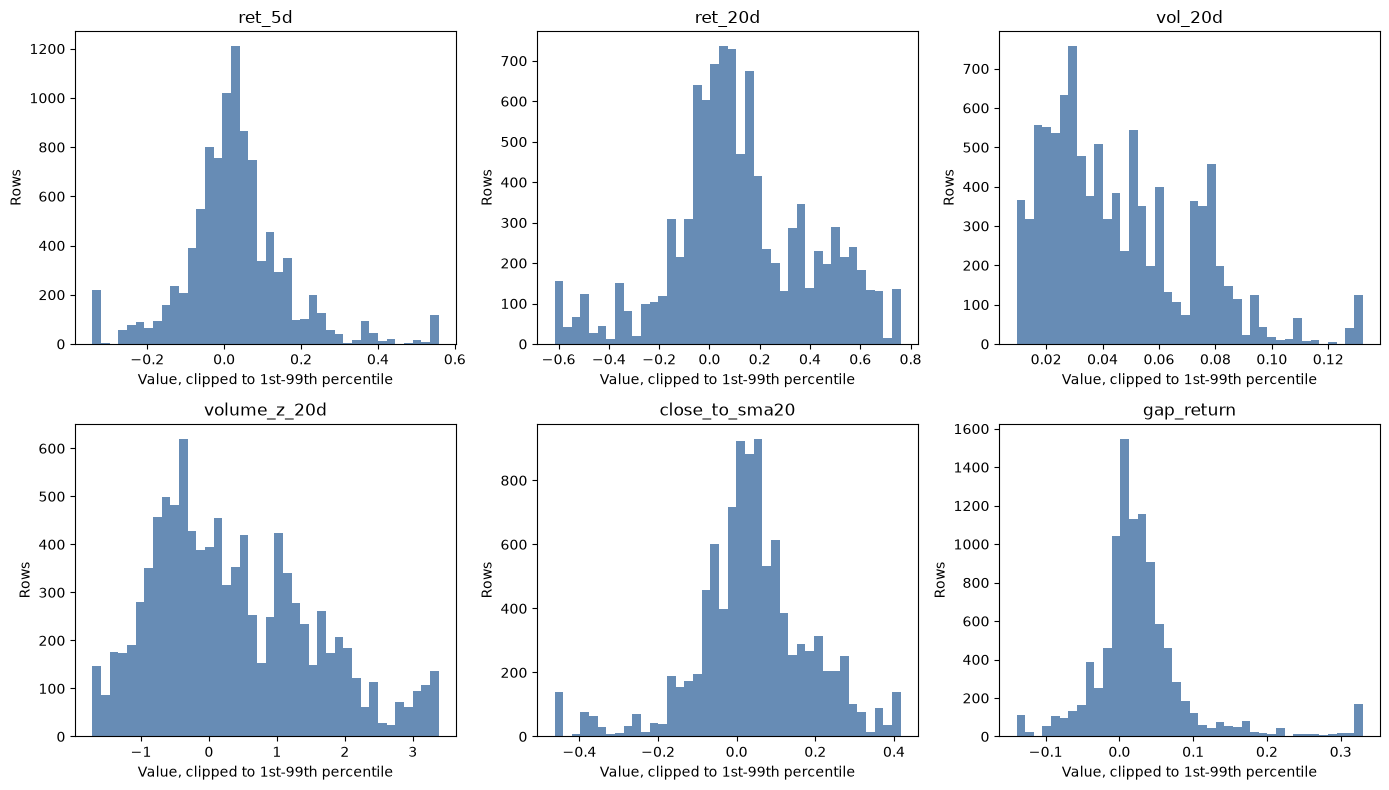

In [18]:
fig, axes = plt.subplots(2, 3, figsize=(14, 8))
selected_features = ["ret_5d", "ret_20d", "vol_20d", "volume_z_20d", "close_to_sma20", "gap_return"]

for ax, column in zip(axes.ravel(), selected_features):
    clipped = modeling[column].clip(modeling[column].quantile(0.01), modeling[column].quantile(0.99))
    ax.hist(clipped, bins=40, color="#4C78A8", alpha=0.85)
    ax.set_title(column)
    ax.set_xlabel("Value, clipped to 1st-99th percentile")
    ax.set_ylabel("Rows")

plt.tight_layout()

## Abnormal Score And Future Return Diagnostics

In [19]:
abnormal_summary_by_split = (
    modeling.groupby("split")[["future_return_1d", "rolling_vol_20d", "abnormal_score"]]
    .describe(percentiles=[0.05, 0.25, 0.5, 0.75, 0.95])
    .round(4)
)

abnormal_summary_by_split

future_return_1d                                                  \
                      count    mean     std     min      5%     25%     50%   
split                                                                         
test                  994.0  0.0030  0.0560 -0.2106 -0.0902 -0.0219  0.0027   
train                7947.0  0.0017  0.0607 -0.3318 -0.1027 -0.0233  0.0010   
validation            999.0  0.0041  0.0613 -0.3318 -0.0943 -0.0229  0.0015   

                                   rolling_vol_20d                          \
               75%     95%     max           count    mean     std     min   
split                                                                        
test        0.0280  0.1047  0.2432           994.0  0.0464  0.0269  0.0072   
train       0.0278  0.1092  0.2432          7947.0  0.0459  0.0264  0.0055   
validation  0.0289  0.1092  0.2432           999.0  0.0460  0.0255  0.0080   

                                                           abnormal_score  \
                5%     25%     50%     75%     95%     max          count   
split                                                                       
test        0.0134  0.0259  0.0410  0.0626  0.0902  0.1741          994.0   
train       0.0140  0.0255  0.0396  0.0608  0.0889  0.1740         7947.0   
validation  0.0156  0.0265  0.0396  0.0597  0.0907  0.1553          999.0   

                                                                            \
              mean     std     min      5%     25%     50%     75%     95%   
split                                                                        
test        0.1293  1.3570 -5.3556 -1.9975 -0.5285  0.0629  0.7975  2.3261   
train       0.0704  1.3611 -7.2100 -2.1332 -0.6340  0.0296  0.7637  2.3220   
validation  0.0807  1.3362 -4.5129 -2.0076 -0.6379  0.0312  0.7646  2.3133   

                    
               max  
split               
test        6.7810  
train       6.7810  
validation  6.6048

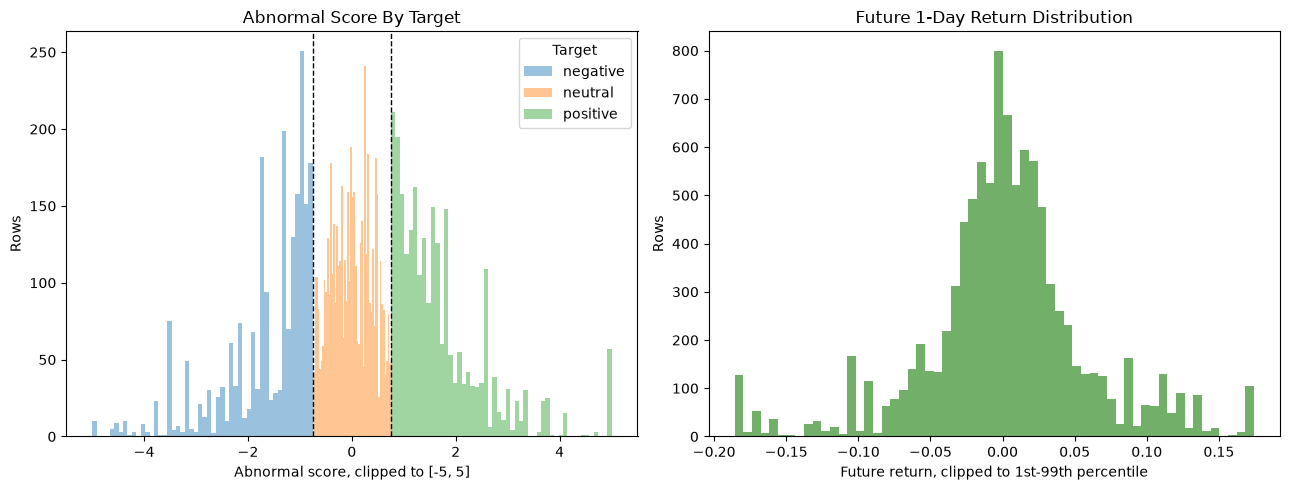

In [20]:
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

score_clip = modeling["abnormal_score"].clip(-5, 5)
for target, group in modeling.assign(score_clip=score_clip).groupby("target"):
    axes[0].hist(group["score_clip"], bins=50, alpha=0.45, label=target)
axes[0].axvline(-0.75, color="black", linestyle="--", linewidth=1)
axes[0].axvline(0.75, color="black", linestyle="--", linewidth=1)
axes[0].set_title("Abnormal Score By Target")
axes[0].set_xlabel("Abnormal score, clipped to [-5, 5]")
axes[0].set_ylabel("Rows")
axes[0].legend(title="Target")

return_clip = modeling["future_return_1d"].clip(
    modeling["future_return_1d"].quantile(0.01),
    modeling["future_return_1d"].quantile(0.99),
)
axes[1].hist(return_clip, bins=60, color="#59A14F", alpha=0.85)
axes[1].set_title("Future 1-Day Return Distribution")
axes[1].set_xlabel("Future return, clipped to 1st-99th percentile")
axes[1].set_ylabel("Rows")

plt.tight_layout()

## Volatility Regime And Text-Length Views

These are descriptive subgroup checks. They should inform later error analysis, not drive test-set tuning.

In [21]:
analysis = modeling.copy()
analysis["vol_regime"] = np.where(
    analysis["rolling_vol_20d"] >= analysis["rolling_vol_20d"].median(),
    "high_volatility",
    "low_volatility",
)
analysis["post_char_count"] = analysis["original"].fillna("").astype(str).str.len()
analysis["post_length_bin"] = pd.qcut(
    analysis["post_char_count"],
    q=4,
    labels=["short", "medium_short", "medium_long", "long"],
    duplicates="drop",
)

display(pd.crosstab(analysis["vol_regime"], analysis["target"], normalize="index").round(3))
display(pd.crosstab(analysis["post_length_bin"], analysis["target"], normalize="index").round(3))

target,negative,neutral,positive
vol_regime,,,
high_volatility,0.201,0.573,0.226
low_volatility,0.231,0.490,0.279


target,negative,neutral,positive
post_length_bin,,,
short,0.215,0.537,0.248
medium_short,0.224,0.536,0.240
medium_long,0.220,0.525,0.256
long,0.206,0.527,0.267


## Representative Rows For Report Planning

In [22]:
representative_columns = [
    "split",
    "ticker",
    "post_date",
    "event_date",
    "target",
    "future_return_1d",
    "abnormal_score",
    "senti_label",
    "emo_label",
    "original",
]

representative_rows = (
    modeling.sort_values("abnormal_score")
    .groupby("target", group_keys=False)
    .head(3)[representative_columns]
    .sort_values(["target", "abnormal_score"])
)

representative_rows

,split,ticker,post_date,event_date,target,future_return_1d,abnormal_score,senti_label,emo_label,original
7707,train,UPS,2020-10-27,2020-10-27,negative,-0.088153,-7.210027,bullish,excitement,$UPS it’s burnin boyyyyzzzzz. Time to get bank. 💯🏹💰
8801,train,BABA,2020-12-23,2020-12-23,negative,-0.133422,-7.025845,bearish,confusion,$BABA ...most of the market is now turning green while this remains red. So much for the holiday rally. 🤷‍♂️
8800,train,BABA,2020-12-23,2020-12-23,negative,-0.133422,-7.025845,bearish,ambiguous,$BABA I feel sorry for anyone longs above $290. Gap down after Gap down. I come back & check this trash to remind myself not to fall in love with a stock. A...
5234,train,WMT,2020-08-04,2020-08-04,neutral,-0.013902,-0.748283,bullish,optimism,$WMT this guy is a troll - someone axe him. But hey to those that have held calls/accumulated as premiums got smashed last 10-14days now we have some genuin...
7424,train,XOM,2020-10-08,2020-10-08,neutral,-0.014748,-0.747657,bullish,anxiety,$XOM I 👀 a crossover forming on the MACD. Bottom in?!?!
5322,train,TSLA,2020-08-08,2020-08-10,neutral,-0.031144,-0.747184,bearish,anxiety,"$TSLA Perhaps, the US may deserve a democrat government. \nI don`t wish this to you, but still want to bet that it`s crashing down on 19.08. \nThis will nev..."
461,test,NFLX,2020-07-07,2020-07-07,positive,0.019507,0.754283,bullish,anxiety,$NFLX Well that didn’t last long..🤨Have no fear it will retest $500 soon..
4029,train,LOW,2020-05-21,2020-05-21,positive,0.013345,0.755344,bullish,optimism,$LOW looks like this is the safe play for the day🤗🤗🤗🤗🤗🤗🤗
8152,train,AMZN,2020-11-24,2020-11-24,positive,0.021491,0.757638,bearish,depression,$AMZN my call options are doomed ! 😭😭😭


## Notes

- The modeling dataset retained most rows after alignment; dropped rows should be reviewed before modeling, especially ticker-specific cases with limited price history.
- The target is imbalanced toward `neutral`, so macro F1 should remain the main comparison metric.
- Leakage checks pass when every `feature_cutoff_date` precedes `event_date` and every `target_end_date` follows `event_date`.